In [1]:
%matplotlib inline
import random
import torch
from d2l import torch as d2l

In [2]:
def synthetic_data(w,b,num_examples):
    x=torch.normal(0,1,(num_examples,len(w)))#生成特征矩阵 X
    y=torch.matmul(x,w)+b#计算 xw，然后加上偏置 b
    y+=torch.normal(0,0.01,y.shape)#加上了一个均值为 0、标准差为 0.01 的随机噪声
    return x,y.reshape((-1,1))
true_w=torch.tensor([2,-3.4])
true_b=4.2
features,labels=synthetic_data(true_w,true_b,1000)

In [3]:
print('features:',features[0],'\nlable:',labels[0])

features: tensor([0.1138, 0.2206]) 
lable: tensor([3.6887])


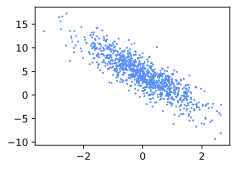

In [4]:
d2l.set_figsize()
d2l.plt.scatter(features[:,1].detach().numpy(),
               labels.detach().numpy(),1);

In [5]:
def data_iter(batch_size,features,labels):
    num_examples=len(features)
    indices=list(range(num_examples))
    random.shuffle(indices)
    for i in range(0,num_examples,batch_size):
        batch_indices = torch.tensor(
            indices[i:min(i+batch_size,num_examples)])
        yield features[batch_indices],labels[batch_indices]
batch_size = 10
for x,y in data_iter(batch_size,features,labels):
    print(x,'\n',y)
    break

tensor([[ 0.4037, -0.3716],
        [ 0.9549,  0.5771],
        [-0.5878,  0.2189],
        [ 1.0237,  0.5706],
        [-0.0502,  0.0225],
        [ 0.6360, -1.6691],
        [ 1.2640, -0.9668],
        [-1.5212, -0.5537],
        [-1.6542, -0.7484],
        [ 1.0380, -0.4146]]) 
 tensor([[ 6.2679],
        [ 4.1423],
        [ 2.2869],
        [ 4.2975],
        [ 4.0238],
        [11.1451],
        [10.0319],
        [ 3.0475],
        [ 3.4432],
        [ 7.6756]])


In [6]:
#定义初始化模型参数
w=torch.normal(0,0.01,size=(2,1),requires_grad=True)
b=torch.zeros(1,requires_grad=True)

In [7]:
#定义模型
def linreg(x,w,b):
    return torch.matmul(x,w)+b

In [8]:
#定义损失函数
def squared_loss(y_hat,y):
    return (y_hat-y.reshape(y_hat.shape))**2/2#均方损失

In [9]:
#定义优化算法
def sgd(params,lr,batch_size):
    with torch.no_grad():
        for param in params:
            param-=lr*param.grad/batch_size #新参数 = 旧 - 学习率 × 梯度
            param.grad.zero_()

In [10]:
#训练过程
lr = 0.03
num_epochs=3
net=linreg
loss=squared_loss
for epoch in range(num_epochs):
    for x,y in data_iter(batch_size,features,labels):
        l=loss(net(x,w,b),y)#损失
        l.sum().backward()#梯度
        sgd([w,b],lr,batch_size)#更新参数
    with torch.no_grad():
        train_l=loss(net(features,w,b),labels)
        print(f'epoch {epoch + 1}, loss {float(train_l.mean()):f}')

epoch 1, loss 0.036517
epoch 2, loss 0.000131
epoch 3, loss 0.000049


In [11]:
print(f'w的估计误差: {true_w - w.reshape(true_w.shape)}')
print(f'b的估计误差: {true_b - b}')

w的估计误差: tensor([-0.0002, -0.0008], grad_fn=<SubBackward0>)
b的估计误差: tensor([-7.5340e-05], grad_fn=<RsubBackward1>)


#

In [12]:
#简洁实现
import numpy as np
import torch
from torch.utils import data
from d2l import torch as d2l
#生成数据集
true_b =4.2
true_w=torch.tensor([2,-3.4])
features,labels=d2l.synthetic_data(true_w,true_b,1000)

In [13]:
#读取数据集
def load_array(data_arrays,batch_size,is_train=True):
    dataset = data.TensorDataset(*data_arrays)
    return data.DataLoader(dataset,batch_size,shuffle=True)
batch_size = 10
data_iter=load_array((features,labels),batch_size)

In [14]:
next(iter(data_iter))

[tensor([[-0.5347, -1.3699],
         [-0.1548, -0.2366],
         [-0.5160,  0.5027],
         [ 0.5252,  0.6710],
         [ 2.3469,  0.8733],
         [ 0.2779, -0.6056],
         [-0.7098,  0.8796],
         [ 0.5550, -0.4877],
         [-0.4674, -0.6249],
         [ 2.4041,  0.1430]]),
 tensor([[ 7.7982],
         [ 4.7126],
         [ 1.4682],
         [ 2.9807],
         [ 5.9084],
         [ 6.8069],
         [-0.1999],
         [ 6.9723],
         [ 5.3848],
         [ 8.5291]])]

In [15]:
#定义模型
from torch import nn
net = nn.Sequential(nn.Linear(2,1))

In [16]:
#初始化模型参数
net[0].weight.data.normal_(0,0.01)
net[0].bias.data.fill_(0)

tensor([0.])

In [17]:
#定义损伤函数
loss = nn.MSELoss()

In [18]:
#定义优化算法
trainer = torch.optim.SGD(net.parameters(),lr=0.03)

In [19]:
#训练
num_epochs = 3
for epoch in range(num_epochs):
    for x,y in data_iter:
        l=loss(net(x),y)
        trainer.zero_grad()
        l.backward()
        trainer.step()
    l = loss(net(features),labels)
    print(f'epoch {epoch + 1}, loss {l:f}')

epoch 1, loss 0.000350
epoch 2, loss 0.000100
epoch 3, loss 0.000099


In [20]:
w = net[0].weight.data
print('w的估计误差：', true_w - w.reshape(true_w.shape))
b = net[0].bias.data
print('b的估计误差：', true_b - b)

w的估计误差： tensor([-0.0002, -0.0003])
b的估计误差： tensor([0.0005])
